In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scikit_posthocs as sp
import matplotlib.text as mtext

from scipy.stats import friedmanchisquare, studentized_range

### VERIFICAR ALGORITMOS

In [3]:
df = pd.read_csv("friedman_ready\\all_qg_results.csv")

tabela_contagem = (
    df
    .groupby(["algorithm", "dataset"])
    .size()
    .reset_index(name="n_repeticoes")
)

print(tabela_contagem)

# Verifica se todos os pares algoritmo-base têm 10 repetições
problemas = tabela_contagem[tabela_contagem["n_repeticoes"] != 10]

print("Pares com número diferente de 10 repetições:")
print(problemas)

                    algorithm      dataset  n_repeticoes
0         SD-pn-freq-2_binary         alon            10
1         SD-pn-freq-2_binary   burczynski            10
2         SD-pn-freq-2_binary    chiaretti            10
3         SD-pn-freq-2_binary         chin            10
4         SD-pn-freq-2_binary     chowdary            10
..                        ...          ...           ...
869  SSDP+-pn-width-8_nominal       sorlie            10
870  SSDP+-pn-width-8_nominal  subramanian            10
871  SSDP+-pn-width-8_nominal         tian            10
872  SSDP+-pn-width-8_nominal         west            10
873  SSDP+-pn-width-8_nominal         yeoh            10

[874 rows x 3 columns]
Pares com número diferente de 10 repetições:
Empty DataFrame
Columns: [algorithm, dataset, n_repeticoes]
Index: []


### GERAR DIAGRAMA Simples

In [ ]:
def gerar_cd_diagram(
    df,
    metric_col="quality",
    dataset_col="dataset",
    algorithm_col="algorithm",
    repetition_col="repetition",
    higher_is_better=True,
    alpha=0.05,
    output_path="critical_difference_diagram.png"
):
    # 1. Agrega as repetições.
    # Cada linha final deve representar o desempenho médio de um algoritmo em uma base.
    df_mean = (
        df
        .groupby([dataset_col, algorithm_col], as_index=False)[metric_col]
        .mean()
    )

    # 2. Cria matriz: linhas = bases, colunas = algoritmos/configurações.
    scores = df_mean.pivot(
        index=dataset_col,
        columns=algorithm_col,
        values=metric_col
    )

    # 3. Garante que todos os algoritmos foram avaliados nas mesmas bases.
    if scores.isna().any().any():
        missing = scores.isna().sum().sum()
        raise ValueError(
            f"A matriz possui {missing} valores ausentes. "
            "Para Friedman/CD diagram, todos os algoritmos precisam ter resultado "
            "para as mesmas bases."
        )

    # 4. Teste de Friedman.
    stat, p_value = friedmanchisquare(
        *[scores[col].values for col in scores.columns]
    )

    print(f"Friedman statistic = {stat:.6f}")
    print(f"p-value = {p_value:.6g}")

    # 5. Calcula ranking por base.
    # Para métricas de qualidade, normalmente maior é melhor.
    # rank 1 = melhor algoritmo naquela base.
    ranks = scores.rank(
        axis=1,
        method="average",
        ascending=not higher_is_better
    )

    avg_ranks = ranks.mean(axis=0).sort_values()

    # 6. Pós-hoc de Nemenyi.
    # Esse é o pós-hoc clássico associado ao Critical Difference Diagram.
    p_matrix = sp.posthoc_nemenyi_friedman(scores)
    p_matrix = p_matrix.loc[avg_ranks.index, avg_ranks.index]

    # 7. Calcula a Critical Difference (CD) para exibir no gráfico.
    n_datasets = scores.shape[0]
    n_algorithms = scores.shape[1]

    q_alpha = studentized_range.ppf(
        1 - alpha,
        n_algorithms,
        np.inf
    ) / np.sqrt(2)

    cd = q_alpha * np.sqrt(
        n_algorithms * (n_algorithms + 1) / (6 * n_datasets)
    )

    print(f"CD = {cd:.6f}")
    print("\nRankings médios:")
    print(avg_ranks)

    # 8. Plota o diagrama.
    plt.figure(figsize=(14, max(4, 0.25 * n_algorithms)), dpi=300)

    ################
    sp.critical_difference_diagram(
        ranks=avg_ranks,
        sig_matrix=p_matrix,
        alpha=alpha,
        cd=cd,
        label_fmt_left="{label} ({rank:.2f})",
        label_fmt_right="({rank:.2f}) {label}"
    )

    #plt.title(title)
    plt.tight_layout()
    plt.savefig(output_path, bbox_inches="tight")
    plt.show()

    return {
        "friedman_statistic": stat,
        "friedman_p_value": p_value,
        "critical_difference": cd,
        "avg_ranks": avg_ranks,
        "p_matrix": p_matrix
    }

### Versão com barra ajustavel

In [5]:
def gerar_cd_diagram(
    df,
    metric_col="quality",
    dataset_col="dataset",
    algorithm_col="algorithm",
    repetition_col="repetition",
    higher_is_better=True,
    alpha=0.05,
    output_path="critical_difference_diagram.png",
    title="Critical Difference Diagram"
):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import scikit_posthocs as sp

    from scipy.stats import friedmanchisquare, studentized_range

    df_mean = (
        df
        .groupby([dataset_col, algorithm_col], as_index=False)[metric_col]
        .mean()
    )

    scores = df_mean.pivot(
        index=dataset_col,
        columns=algorithm_col,
        values=metric_col
    )

    if scores.isna().any().any():
        missing = scores.isna().sum().sum()
        raise ValueError(
            f"A matriz possui {missing} valores ausentes. "
            "Todos os algoritmos precisam ter resultado para as mesmas bases."
        )

    stat, p_value = friedmanchisquare(
        *[scores[col].values for col in scores.columns]
    )

    print(f"Friedman statistic = {stat:.6f}")
    print(f"p-value = {p_value:.6g}")

    ranks = scores.rank(
        axis=1,
        method="average",
        ascending=not higher_is_better
    )

    avg_ranks = ranks.mean(axis=0).sort_values()

    p_matrix = sp.posthoc_nemenyi_friedman(scores)
    p_matrix = p_matrix.loc[avg_ranks.index, avg_ranks.index]

    n_datasets = scores.shape[0]
    n_algorithms = scores.shape[1]

    q_alpha = studentized_range.ppf(
        1 - alpha,
        n_algorithms,
        np.inf
    ) / np.sqrt(2)

    cd = q_alpha * np.sqrt(
        n_algorithms * (n_algorithms + 1) / (6 * n_datasets)
    )

    print(f"CD = {cd:.6f}")
    print("\nRankings médios:")
    print(avg_ranks)

    fig, ax = plt.subplots(
        figsize=(16, max(4, 0.28 * n_algorithms)),
        dpi=300
    )
    
    # Deixa o scikit-posthocs desenhar a barra do CD na posição correta
    sp.critical_difference_diagram(
        ranks=avg_ranks,
        sig_matrix=p_matrix,
        alpha=alpha,
        cd=cd,
        label_fmt_left="{label} ({rank:.2f})",
        label_fmt_right="({rank:.2f}) {label}",
        ax=ax
    )

    # Sobe a barra original do CD
    cd_bar_shift = 0.48

    cd_line_candidates = []

    for line in ax.lines:
        ydata = np.asarray(line.get_ydata(), dtype=float)

        if len(ydata) > 0 and np.all(np.isfinite(ydata)):
            cd_line_candidates.append((line, ydata.mean()))

    if cd_line_candidates:
        max_mean_y = max(mean_y for _, mean_y in cd_line_candidates)

        for line, mean_y in cd_line_candidates:
            if abs(mean_y - max_mean_y) < 1e-6:
                ydata = np.asarray(line.get_ydata(), dtype=float)
                line.set_ydata(ydata + cd_bar_shift)

    # Procura o texto original do CD
    cd_text_obj = None

    for obj in ax.findobj(mtext.Text):
        text = obj.get_text()
        if isinstance(text, str) and text.strip().startswith("CD"):
            cd_text_obj = obj
            break

    # Esconde o texto original e redesenha mais acima
    if cd_text_obj is not None:
        x_cd, y_cd = cd_text_obj.get_position()
        transform_cd = cd_text_obj.get_transform()
        cd_text_obj.set_visible(False)

        ax.text(
            x_cd,
            y_cd + cd_bar_shift + 0.16,
            f"CD = {cd:.0f}",
            transform=transform_cd,
            ha=cd_text_obj.get_ha(),
            va=cd_text_obj.get_va(),
            fontsize=cd_text_obj.get_fontsize(),
            clip_on=False
        )

    ax.set_title(title, pad=40)

    plt.tight_layout()
    plt.savefig(output_path, bbox_inches="tight")
    plt.show()

    return {
        "friedman_statistic": stat,
        "friedman_p_value": p_value,
        "critical_difference": cd,
        "avg_ranks": avg_ranks,
        "p_matrix": p_matrix
    }

Friedman statistic = 190.855615
p-value = 1.5215e-32
CD = 5.292058

Rankings médios:
algorithm
SMHDD_1.0-freq-8_binary      2.684211
SMHDD_1.0-width-8_binary     3.289474
SMHDD-pn-freq-8_binary       4.315789
SMHDD-pn-width-8_binary      5.736842
SMHDD_1.0-width-4_binary     5.789474
SMHDD_1.0-freq-4_binary      5.894737
SMHDD-pn-freq-4_binary       6.184211
SMHDD-pn-width-4_binary      7.052632
SMHDD-pn-width-2_binary      9.078947
SMHDD-pn-freq-2_binary       9.684211
SD-pn-freq-2_binary         10.368421
SD-pn-freq-8_binary         11.605263
SD-pn-freq-4_binary         12.868421
SD-pn-width-8_binary        13.184211
SD-pn-width-4_binary        13.710526
SD-pn-width-2_binary        14.552632
dtype: float64


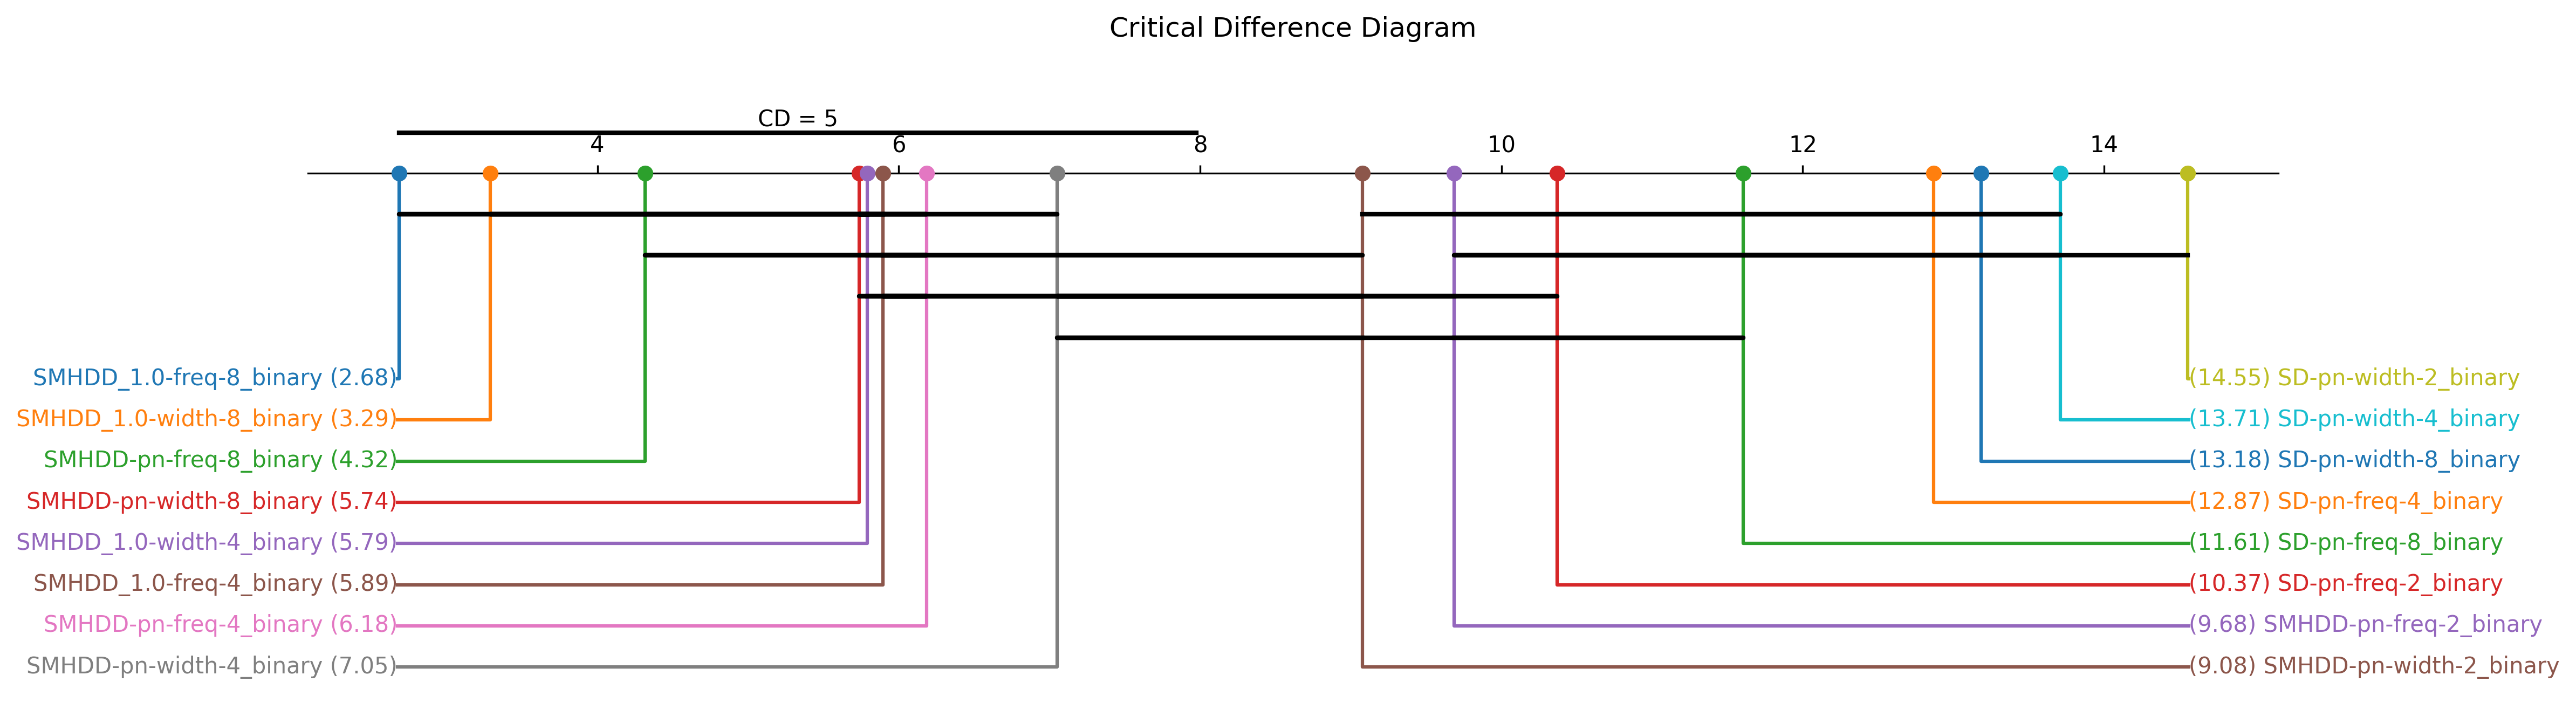

In [6]:
df_qg = pd.read_csv("friedman_ready\\all_qg_results.csv")

df_qg = df_qg[
    (~df_qg["algorithm"].str.startswith("SSDP+", na=False)) &
    (~df_qg["algorithm"].str.contains("nominal|nom", case=False, na=False, regex=True))
].copy()

resultado_qg = gerar_cd_diagram(
    df_qg,
    metric_col="quality",
    higher_is_better=True,
    output_path="new_cd_diagram_qg.png",
)